In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import os
from functions import *



In [3]:
data = pd.read_csv(fullDataPath('BTC'))

In [4]:
# Convert time to datetime if it's not already
data['time'] = pd.to_datetime(data['time'], errors='coerce')
data = data.dropna(subset=['time'])

# Extract date component
data['date'] = data['time'].dt.date

# Group by date and aggregate values (one row per day)
# Hard coded change later
daily_data = (
    data
    .groupby('date')
    .agg(
        close=('close', 'last'),  # Take the last close price of the day
        avg_sentiment=('score', 'mean'),  # Average sentiment for the day
        tweet_count=('score', 'count'),   # Number of observations per day
        volume=('volume', 'last'),          # Total volume for the day
        BB_Lower=('BB_Lower', 'last'),  # Last value of BB lower band
        BB_Middle=('BB_Middle', 'last'),  # Last value of BB middle band
        BB_Upper=('BB_Upper', 'last'),  # Last value of BB upper band
        SMA_50=('SMA_50', 'last'),  # Last value of SMA 50
        Volume_MA_20=('Volume_MA_20', 'last'),  # Last value of Volume MA 20
        value=('value', 'last'),
        value_classification=('value_classification', 'last'),
        OBV=('OBV', 'last')
    )
    .reset_index()
)

# Convert date back to datetime format if needed
daily_data['time'] = pd.to_datetime(daily_data['date'])
daily_data = daily_data.drop('date', axis=1)

# Sort by time
daily_data = daily_data.sort_values('time')
daily_data.set_index('time', inplace=True)
daily_data['gradient'] = daily_data['close'].diff().fillna(0.0)
daily_data


,close,avg_sentiment,tweet_count,volume,BB_Lower,BB_Middle,BB_Upper,SMA_50,Volume_MA_20,value,value_classification,OBV,gradient
time,,,,,,,,,,,,,
2024-07-12,57909.03,0.000000,1,10516.604001,59399.753225,65209.3695,71018.985775,62050.1696,9777.576091,40.0,Neutral,-312056.665872,0.00
2024-07-13,59224.58,0.000000,1,4255.105457,60892.200610,65578.3270,70264.453390,62071.3564,10033.581994,41.0,Neutral,-301540.061870,1315.55
2024-07-14,60808.42,0.000000,1,6132.374031,61558.362035,65688.0010,69817.639965,62032.8448,10590.327203,45.0,Neutral,-297284.956413,1583.84
2024-07-15,64757.16,0.000000,1,20601.733880,61518.185238,65681.3265,69844.467762,61999.4730,10684.678227,48.0,Neutral,-291152.582382,3948.74
2024-07-16,65088.99,0.000000,1,14691.920023,59993.572597,65350.0160,70706.459403,61853.7066,10170.542079,57.0,Neutral,-270550.848503,331.83
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07,108269.84,-0.001550,1,4455.083530,101288.707658,108463.3535,115637.999342,107036.2634,0.000000,52.0,Neutral,-28844.514097,-948.14
2025-07-08,108958.04,0.000000,1,3785.390742,101288.707658,108463.3535,115637.999342,107036.2634,0.000000,50.0,Neutral,-24389.430567,688.20
2025-07-09,111282.85,27.414035,7,7683.832396,101288.707658,108463.3535,115637.999342,107036.2634,0.000000,52.0,Neutral,-20604.039825,2324.81


In [41]:
# Split data into train/test - use first 80% for training
split_idx = int(len(daily_data) * 0.8)
train = daily_data.iloc[:split_idx]
test = daily_data.iloc[split_idx:]

# Prepare training data for Prophet
train_prophet = train.reset_index().rename(columns={'time': 'ds', 'close': 'y'})

m = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
m.add_seasonality(name='weekly', period=7, fourier_order=3)
m.fit(train_prophet)


13:20:44 - cmdstanpy - INFO - Chain [1] start processing
13:20:44 - cmdstanpy - INFO - Chain [1] done processing


In [42]:
# Create future dataframe that includes the test period
test_days = len(test)
future = m.make_future_dataframe(periods=test_days, freq='D')
future


,ds
0,2024-07-12
1,2024-07-13
2,2024-07-14
3,2024-07-15
4,2024-07-16
...,...
360,2025-07-07
361,2025-07-08
362,2025-07-09
363,2025-07-10


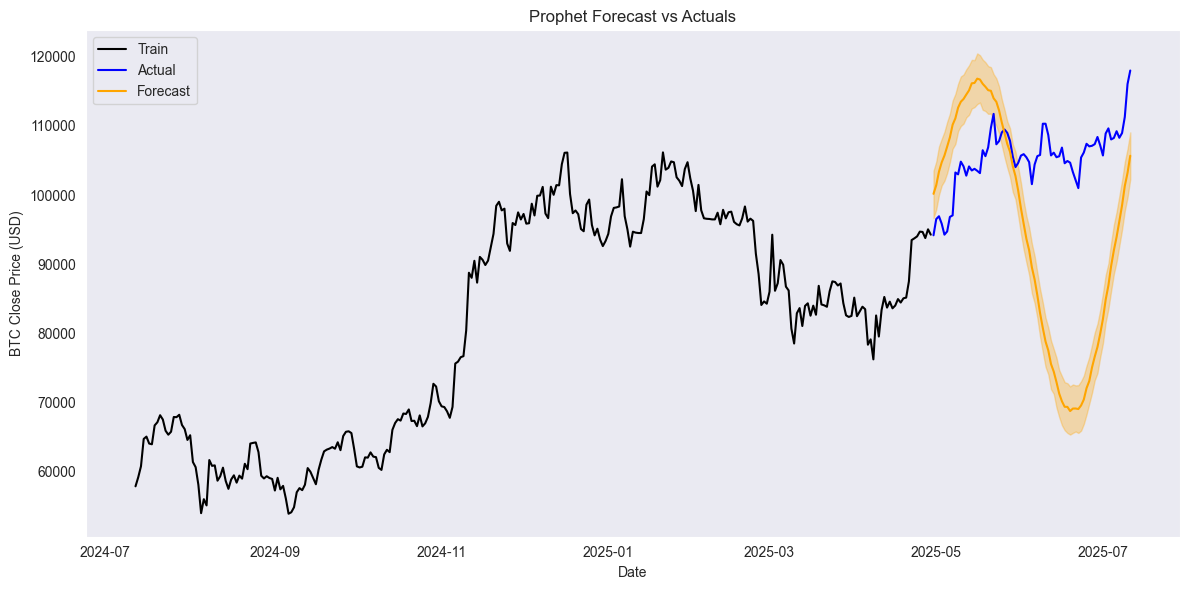

In [43]:
# Generate forecast
df_forecast = m.predict(future)

# Prepare test data with proper column names
test_prophet = test.reset_index().rename(columns={'time': 'ds', 'close': 'y'})

# Extract forecast for the test range - use proper date matching
fcst_test = df_forecast.set_index('ds').loc[test_prophet['ds'], ['yhat','yhat_lower','yhat_upper']]

# Plot results
plt.figure(figsize=(12,6))
plt.plot(train_prophet['ds'], train_prophet['y'], label='Train', color='black')
plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual', color='blue')
plt.plot(fcst_test.index, fcst_test['yhat'], label='Forecast', color='orange')
plt.fill_between(fcst_test.index,
                 fcst_test['yhat_lower'],
                 fcst_test['yhat_upper'],
                 color='orange', alpha=0.3)
plt.title('Prophet Forecast vs Actuals')
plt.xlabel('Date'); plt.ylabel('BTC Close Price (USD)')
plt.legend(); plt.grid(False); plt.tight_layout()
plt.show()


In [44]:
# === Cell 6: 7-Day Sliding Forecast Summary ===
rows = []
dates = fcst_test.index
total = len(dates)
for i in range(0, total - 6):
    block_dates = dates[i:i+7]
    start_date = block_dates[0].strftime('%Y-%m-%d')
    end_date   = block_dates[-1].strftime('%Y-%m-%d')
    block_vals = fcst_test['yhat'].iloc[i:i+7].values
    # Label based on last vs first forecast
    if block_vals[-1] > block_vals[0]:
        label = 'Bullish'
    elif block_vals[-1] < block_vals[0]:
        label = 'Bearish'
    else:
        label = 'Neutral'
    row = {'start': start_date, 'end': end_date, 'label': label}
    for j, v in enumerate(block_vals, start=1):
        row[f'day_{j}'] = v
    rows.append(row)
seq_df = pd.DataFrame(rows)
seq_df.head()

,start,end,label,day_1,day_2,day_3,day_4,day_5,day_6,day_7
0,2025-04-30,2025-05-06,Bullish,100170.137645,101409.466559,103367.234763,104715.876530,105699.026335,106992.844491,108330.830249
1,2025-05-01,2025-05-07,Bullish,101409.466559,103367.234763,104715.876530,105699.026335,106992.844491,108330.830249,110155.627566
2,2025-05-02,2025-05-08,Bullish,103367.234763,104715.876530,105699.026335,106992.844491,108330.830249,110155.627566,111075.081170
3,2025-05-03,2025-05-09,Bullish,104715.876530,105699.026335,106992.844491,108330.830249,110155.627566,111075.081170,112624.183011
4,2025-05-04,2025-05-10,Bullish,105699.026335,106992.844491,108330.830249,110155.627566,111075.081170,112624.183011,113477.566650
